# OEMOF Step 3 — District Heating Optimization Model

This notebook builds and solves an oemof.solph energy system model for a district heating network.

**Structure**
1. Imports  
2. Inputs & parameters  
3. Energy system (buses, sources, loads, powerplants)  
4. Optimize  
5. Results & export


## 1. Imports

In [160]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model,
                         create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph


## 2. Inputs

Load your time series into a DataFrame named `data`.

Expected columns:
- `gas_price_Euro_Per_MWh`
- `electricity_price_Euro_Per_MWh`
- `biomass_Euro_Per_MWh`
- `waste_Euro_Per_MWh`
- `thermal_demand_MW`
- `irradiance_direct_MW/m2`
- `irradiance_diffuse_MW/m2`


In [161]:
filename = r"../2_inputs/3_OEMOF/input_data.csv"
data = pd.read_csv(filename)
solver = "gurobi"
solver_verbose = False

print(data.columns.tolist())


['thermal_demand_MW', 'electricity_price_Euro_Per_MWh', 'co2_price', 'gas_price_Euro_Per_MWh', 'biomass_Euro_Per_MWh', 'waste_Euro_Per_MWh', 'irradiance_direct_MW/m2', 'irradiance_diffuse_MW/m2']


### 2.1 Model sizing (fixed capacities)

All capacities are fixed inputs (no investment optimization in this step).


In [162]:
capacity_gas_heat = 3      # MW
capacity_biomass_chp = 4   # MW (fuel capacity as used in CHP input flow)
capacity_wte_chp = 4       # MW (fuel capacity as used in CHP input flow)
max_heat_hp = 3            # MW (thermal output limit)
area_m2 = 4000             # m2 (solar thermal collector area)


## 3. Energy System

### 3.0 Time index and EnergySystem

In [163]:
datetimeindex = create_time_index(2023, number=len(data))[:len(data)]
data.index = datetimeindex
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)


### 3.1 Buses

Buses represent energy carriers (electricity, heat, fuels, waste heat).


In [164]:
electrical_bus = Bus(label="electrical_bus")
thermal_bus    = Bus(label="thermal_bus")
gas_bus        = Bus(label="gas_bus")
biomass_bus    = Bus(label="biomass_bus")
waste_bus      = Bus(label="waste_bus")
wasteheat_bus  = Bus(label="wasteheat_bus")

energysystem.add(
    electrical_bus, thermal_bus, gas_bus,
    biomass_bus, waste_bus, wasteheat_bus
)


### 3.2 Sources

Sources inject energy into the system:
- fuels (gas, biomass, waste)
- electricity grid import
- exogenous waste heat (limited supply)


In [165]:
energysystem.add(
    Source(
        label="natural_gas",
        outputs={gas_bus: Flow(variable_costs=data["gas_price_Euro_Per_MWh"])},
    ),
    Source(
        label="electricity_grid",
        outputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"])},
    ),
    Source(
        label="biomass",
        outputs={biomass_bus: Flow(variable_costs=data["biomass_Euro_Per_MWh"])},
    ),
    Source(
        label="waste",
        outputs={waste_bus: Flow(variable_costs=data["waste_Euro_Per_MWh"])},
    ),
    Source(
        label="waste_heat",
        outputs={wasteheat_bus: Flow(variable_costs=12, nominal_value=0.7, max=1.0)}, #MW #Waste heat cost 12 Eur/MWh
    ),
)


### 3.3 Loads

- Heat demand is modeled as a fixed sink profile (normalized by peak).
- Electricity export is modeled as a sink with **negative variable cost** (revenue).


In [166]:
thermal_peak = float(data["thermal_demand_MW"].max())

energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={
            thermal_bus: Flow(
                nominal_value=thermal_peak,
                fix=data["thermal_demand_MW"] / thermal_peak,
            )
        },
    ),
    Sink(
        label="excess_electricity",
        inputs={
            electrical_bus: Flow(
                variable_costs=data["electricity_price_Euro_Per_MWh"] * -1
            )
        },
    ),
)


### 3.4 Powerplants

This section adds conversion technologies:
- 3.4.1 Gas boiler (Converter)
- 3.4.2 Biomass CHP (ExtractionTurbineCHP)
- 3.4.3 Waste-to-energy CHP (ExtractionTurbineCHP)
- 3.4.4 Heat pump (Converter) — COP formulation
- 3.4.5 Solar thermal (Source)


#### 3.4.1 Gas boiler (heat-only)

- Input: `gas_bus`
- Output: `thermal_bus`
- Efficiency: `efficiency_gas_heat`


In [167]:
# ------------------------------------------------------------------
# Gas boiler operational constraints (from datasheet)
# ------------------------------------------------------------------
efficiency_gas_heat = 0.93
min_load_gas = 0.10        # 10% minimum load
warm_start_h = 0.08       # hours (documented, not explicitly modeled)
cold_start_h = 0.30       # hours (documented, not explicitly modeled)

# With hourly time steps, any start occupies at least 1 timestep
min_uptime_steps = 1

# Variable O&M only (fixed O&M handled in post-processing)
vom_heat = 0.64            # €/MWh_th

# Annual fixed costs for gas boiler (for post-processing)
fixed_costs_gas = 1063.37*capacity_gas_heat  # €euro/year -If we want compute after postprocessing

energysystem.add(
    Converter(
        label="heat_gas",
        inputs={gas_bus: solph.Flow()},
        outputs={
            thermal_bus: solph.Flow(
                nominal_value=capacity_gas_heat,
                min=min_load_gas,
                variable_costs=vom_heat,
                nonconvex=solph.NonConvex(
                    minimum_uptime=min_uptime_steps,
                    initial_status=0,
                    startup_costs=cold_start_h * data["gas_price_Euro_Per_MWh"] * capacity_gas_heat,
                    shutdown_costs=0
                ),
            )
        },
        conversion_factors={thermal_bus: efficiency_gas_heat},
    )
)

print(
    f"Gas boiler constraints: "
    f"min load = {min_load_gas*100:.0f}%, "
    f"warm start = {warm_start_h} h, "
    f"cold start = {cold_start_h} h (documented)."
)


Gas boiler constraints: min load = 10%, warm start = 0.08 h, cold start = 0.3 h (documented).


#### 3.4.2 Biomass CHP (ExtractionTurbineCHP)

- Fuel input: `biomass_bus`
- Outputs: electricity + heat
- Condensing mode: electric efficiency specified via `conversion_factor_full_condensation`


In [168]:
# -----------------------------
# Biomass CHP (capacity = 4 MW_fuel input)
# -----------------------------

# Efficiencies (datasheet-aligned)
efficiency_biomass_chp_elc = 0.14
efficiency_biomass_chp_th_rel = 0.97
efficiency_biomass_chp_th = (1 - efficiency_biomass_chp_elc) * efficiency_biomass_chp_th_rel

# Condensing-mode electric efficiency (proxy: nameplate)
eta_el_cond_bio = 0.15

# Variable O&M (datasheet)
vom_el_bio = 9.80   # €/MWh_el
vom_th_bio = 1.45   # €/MWh_th

# Annual fixed costs for biomas CHP (for post-processing)
fixed_costs_biomass = 42747.58*capacity_biomass_chp  # €euro/year -If we want compute after postprocessing

# Operational constraints (datasheet)
biomass_min_load = 0.20  # 20%

# Reasonable UC constraints for biomass CHP (hourly model)
biomass_min_uptime = 48
biomass_min_downtime = 24

# Availability (forced 3% + planned 3 weeks/year)
availability_bio = 1 - 0.03 - (3 / 52)

# Startup/shutdown costs (reasonable cycling penalty)
# Scale with implied MW_el at full load:
bio_p_el_full = capacity_biomass_chp * efficiency_biomass_chp_elc  # 0.56 MW_el
# bio_startup_cost = 5000.0 * bio_p_el_full     # €/MW_el/start * MW_el
# bio_shutdown_cost = 0.2 * bio_startup_cost
bio_startup_cost = 0.5 * capacity_biomass_chp * data["biomass_Euro_Per_MWh"] 
bio_shutdown_cost = 0.2 * capacity_biomass_chp * data["biomass_Euro_Per_MWh"]

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="chp_biomass",
        inputs={
            biomass_bus: Flow(
                nominal_value=capacity_biomass_chp,  # MW_fuel
                min=biomass_min_load,
                max=availability_bio,
                nonconvex=solph.NonConvex(
                    startup_costs=bio_startup_cost,
                    shutdown_costs=bio_shutdown_cost,
                    minimum_uptime=biomass_min_uptime,
                    minimum_downtime=biomass_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(variable_costs=vom_el_bio),
            thermal_bus: Flow(variable_costs=vom_th_bio),
        },
        conversion_factors={
            electrical_bus: efficiency_biomass_chp_elc,
            thermal_bus: efficiency_biomass_chp_th,
        },
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_bio,
        },
    )
)

print(
    f"Biomass CHP (fuel cap={capacity_biomass_chp:.2f} MW_fuel): "
    f"P_el_full≈{bio_p_el_full:.2f} MW_el, "
    f"P_th_full≈{capacity_biomass_chp*efficiency_biomass_chp_th:.2f} MW_th, "
    f"availability={availability_bio:.3f}"
)


Biomass CHP (fuel cap=4.00 MW_fuel): P_el_full≈0.56 MW_el, P_th_full≈3.34 MW_th, availability=0.912


#### 3.4.3 Waste-to-energy CHP (ExtractionTurbineCHP)

Same structure as biomass CHP but different efficiencies and costs.


In [169]:
# -----------------------------
# Waste-to-Energy CHP (capacity = 4 MW_fuel input)
# -----------------------------

# Efficiencies (datasheet, annual avg)
efficiency_wte_chp_elc = 0.22
efficiency_wte_chp_th_rel = 0.80
efficiency_wte_chp_th = (1 - efficiency_wte_chp_elc) * efficiency_wte_chp_th_rel  # 0.624

# Condensing-mode electric efficiency (proxy: nameplate 23%)
eta_el_cond_wte = 0.23

# Variable O&M (datasheet)
vom_el_wte = 27.0  # €/MWh_el
vom_th_wte = 6.3   # €/MWh_th

#Fixed costs for WtE CHP (for post-processing)
fixed_costs_wte = 94214.0 * capacity_wte_chp  # €euro/year -If we want compute after postprocessing

# Operational constraints (datasheet)
wte_min_load = 0.20  # 20%
warm_start_h = 0.5   # documented (not resolved hourly)
cold_start_h = 2.0   # documented (not resolved hourly)

# Reasonable UC constraints for WtE (baseload-ish operation)
wte_min_uptime = 48
wte_min_downtime = 24

# Availability (forced 1% + planned 3.01 weeks/year)
availability_wte = 1 - 0.01 - (3.01 / 52)

# Startup/shutdown costs (reasonable cycling penalty)
# Scale with implied MW_el at full load:
wte_p_el_full = capacity_wte_chp * efficiency_wte_chp_elc  # 0.88 MW_el
# wte_startup_cost = 8000.0 * wte_p_el_full   # €/MW_el/start * MW_el
# wte_shutdown_cost = 0.2 * wte_startup_cost
wte_startup_cost = 2 * capacity_wte_chp * data["waste_Euro_Per_MWh"] 
wte_shutdown_cost = 0.2 * capacity_wte_chp * data["waste_Euro_Per_MWh"]

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="waste_to_energy",
        inputs={
            waste_bus: Flow(
                nominal_value=capacity_wte_chp,  # MW_fuel
                min=wte_min_load,
                max=availability_wte,
                nonconvex=solph.NonConvex(
                    startup_costs=wte_startup_cost,
                    shutdown_costs=wte_shutdown_cost,
                    minimum_uptime=wte_min_uptime,
                    minimum_downtime=wte_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(variable_costs=vom_el_wte),
            thermal_bus: Flow(variable_costs=vom_th_wte),
        },
        conversion_factors={
            electrical_bus: efficiency_wte_chp_elc,
            thermal_bus: efficiency_wte_chp_th,
        },
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_wte,
        },
    )
)

print(
    f"WtE CHP (fuel cap={capacity_wte_chp:.2f} MW_fuel): "
    f"P_el_full≈{wte_p_el_full:.2f} MW_el, "
    f"P_th_full≈{capacity_wte_chp*efficiency_wte_chp_th:.2f} MW_th, "
    f"availability={availability_wte:.3f}, "
    f"warm/cold start={warm_start_h}/{cold_start_h} h (documented)"
)



WtE CHP (fuel cap=4.00 MW_fuel): P_el_full≈0.88 MW_el, P_th_full≈2.50 MW_th, availability=0.932, warm/cold start=0.5/2.0 h (documented)


#### 3.4.4 Heat pump (Converter)

Energy balance per 1 MWh_th output:
- Electricity input: **1/COP**
- Source heat input: **(COP−1)/COP**


In [170]:
# -----------------------------
# Heat pump (datasheet-aligned)
# -----------------------------

# Capacity
hp_min_load = 0.25         # 25% minimum load

# COP from datasheet: 430% = 4.30
cop_hp = 4.30

# Costs
vom_hp_th = 2.86           # €/MWh_th (variable O&M total)
startup_cost_per_mw = 10.63  # €/MW_th per startup
fixed_costs_hp = 2126.75 * max_heat_hp  # €euro/year -If we want compute after postprocessing

# Convert startup cost to €/startup for your installed size
# hp_startup_cost = startup_cost_per_mw * max_heat_hp
# hp_shutdown_cost = 0.2 * hp_startup_cost  # reasonable assumption
hp_startup_cost = 1 * max_heat_hp * data["electricity_price_Euro_Per_MWh"]
hp_shutdown_cost = 0.2 * max_heat_hp * data["electricity_price_Euro_Per_MWh"]

# Availability (planned outage 1 week/year, forced outage 0%)
availability_hp = 1 - (1 / 52)

energysystem.add(
    solph.components.Converter(
        label="heat_pump",
        inputs={
            electrical_bus: Flow(),
            wasteheat_bus: Flow(),
        },
        outputs={
            thermal_bus: Flow(
                nominal_value=max_heat_hp,
                min=hp_min_load,
                max=availability_hp,
                variable_costs=vom_hp_th,
                nonconvex=solph.NonConvex(
                    startup_costs=hp_startup_cost,
                    shutdown_costs=hp_shutdown_cost,
                    # optional (keep simple unless you really need it):
                    minimum_uptime=1,
                    minimum_downtime=1,
                    initial_status=0,
                ),
            ),
        },
        conversion_factors={
            electrical_bus: 1 / cop_hp,
            wasteheat_bus: (cop_hp - 1) / cop_hp,
        },
    )
)

# print(
#     f"HP aligned: COP={cop_hp}, min load={hp_min_load*100:.0f}%, "
#     f"availability={availability_hp:.3f}, startup cost={hp_startup_cost:.2f} €/start"
# )

#### 3.4.5 Solar thermal (Source)

Compute an hourly thermal output profile from irradiance and scale it by area.
Model it as a heat Source with:
- `nominal_value = peak output`
- `max = per-unit profile`


In [171]:
##Calculation of solar thermal input profile
tilt_deg = 45
eta = 0.48
annual_input = 1.05
pump_fraction = 0.01

dni = data["irradiance_direct_MW/m2"].clip(lower=0)
dhi = data["irradiance_diffuse_MW/m2"].clip(lower=0)
cosZ = 0.3
ghi = dhi + dni * cosZ

tilt = np.deg2rad(tilt_deg)
Rb = 1.0

G_tilt = (
    dni * Rb +
    dhi * (1 + np.cos(tilt)) / 2 +
    ghi * 0.2 * (1 - np.cos(tilt)) / 2
).clip(lower=0)

G_MWh = G_tilt / 1e6
scale = annual_input / G_MWh.sum()
G_input = G_MWh * scale
G_output = G_input * eta

solar_thermal_MW = G_output * area_m2
pump_MW = pump_fraction * solar_thermal_MW

Q_nominal = float(solar_thermal_MW.max())
solar_profile_pu = (solar_thermal_MW / Q_nominal).values

print("Solar thermal peak (MW):", Q_nominal)
print("Annual thermal output (MWh):", float(solar_thermal_MW.sum()))

# Variable O&M (from table)
vom_solar_th = 0.14887218  # €/MWh_th (from table)
annual_fixed_om_solar = 60.2719657 * Q_nominal  # €/MW_th/year (from table)

print("Solar thermal fixed O&M (documentation only):")
print(f"Installed capacity (Q_nominal): {Q_nominal:.3f} MW_th")
print(f"Annual fixed O&M cost: {annual_fixed_om_solar:.2f} €/year")


energysystem.add(
    Source(
        label="solar_thermal",
        outputs={
            thermal_bus: Flow(
                nominal_value=Q_nominal,      # MW_th
                max=solar_profile_pu,          # availability profile
                variable_costs=vom_solar_th,
            )
        },
    )
)



Solar thermal peak (MW): 1.68767712986937
Annual thermal output (MWh): 2015.9999999999998
Solar thermal fixed O&M (documentation only):
Installed capacity (Q_nominal): 1.688 MW_th
Annual fixed O&M cost: 101.72 €/year


In [172]:
demand_peak = float(data["thermal_demand_MW"].max())
print("Demand peak MW_th:", demand_peak)

# Upper bounds (rough, optimistic)
gas_max = capacity_gas_heat
hp_max = max_heat_hp
bio_max_th = capacity_biomass_chp * ((1-0.14)*0.97)   # if MW_fuel input
wte_max_th = capacity_wte_chp * ((1-0.22)*0.80)       # if MW_fuel input
print("Approx max heat MW_th (no solar):", gas_max + hp_max + bio_max_th + wte_max_th)


Demand peak MW_th: 9.26270011
Approx max heat MW_th (no solar): 11.8328


## 4. Optimize

Solve the model using your solver (default: gurobi).

In [173]:
model = Model(energysystem, name="District Heating Optimization Model")
logging.info("Solving the optimization problem.")

model.solve(
    solver="gurobi",
    solve_kwargs={"tee": True},
    # If you don't have gurobi, try: solver="cbc"
)


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\_plumbing.py:82: FutureWarning: Sequence longer than needed (8760 items instead of 8759). This will be trated as an error in the future.
  warnings.warn(
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmp0y4n77kz.pyomo.lp
Reading time = 1.01 seconds
x1: 350152 rows, 297709 columns, 2030278 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 350152 rows, 297709 columns and 2030278 nonzeros
Model fingerprint: 0x7a866a53
Variable types: 192698 continuous, 105011 integer (105011 binary)
Coefficient statistics:
  Matrix range     [7e-02, 5e+01]
  Objective range  [6e-03, 2e+03]
  Bounds range     [1e-03, 4e+00]
  RHS range        [1e+00, 2e+01]
Presolve removed 219478 rows and 182691 columns
Presolve time: 3.47s
Presolved: 130674 rows, 115018 columns, 1273289 nonzeros
Variable type

{'Problem': [{'Name': 'x1', 'Lower bound': 969020.989245931, 'Upper bound': 969072.4172398407, 'Number of objectives': 1, 'Number of constraints': 350152, 'Number of variables': 297709, 'Number of binary variables': 105011, 'Number of integer variables': 105011, 'Number of continuous variables': 192698, 'Number of nonzeros': 2030278, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Return code': '0', 'Message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Wall time': '41.76200008392334', 'Error rc': 0, 'Time': 43.728243350982666}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

## 5. Results & Export

In [174]:
energysystem.results["main"] = processing.results(model, remove_last_time_point=True)
energysystem.results["meta"] = processing.meta_results(model)

results = energysystem.results["main"]

output_file = os.path.join(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
energysystem.dump(os.getcwd(), "../3_outputs/OEMOF_step3_results.xlsx")
logging.info("Results have been dumped.")

# Quick peek (optional)
# print(list(results.keys())[:5])


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


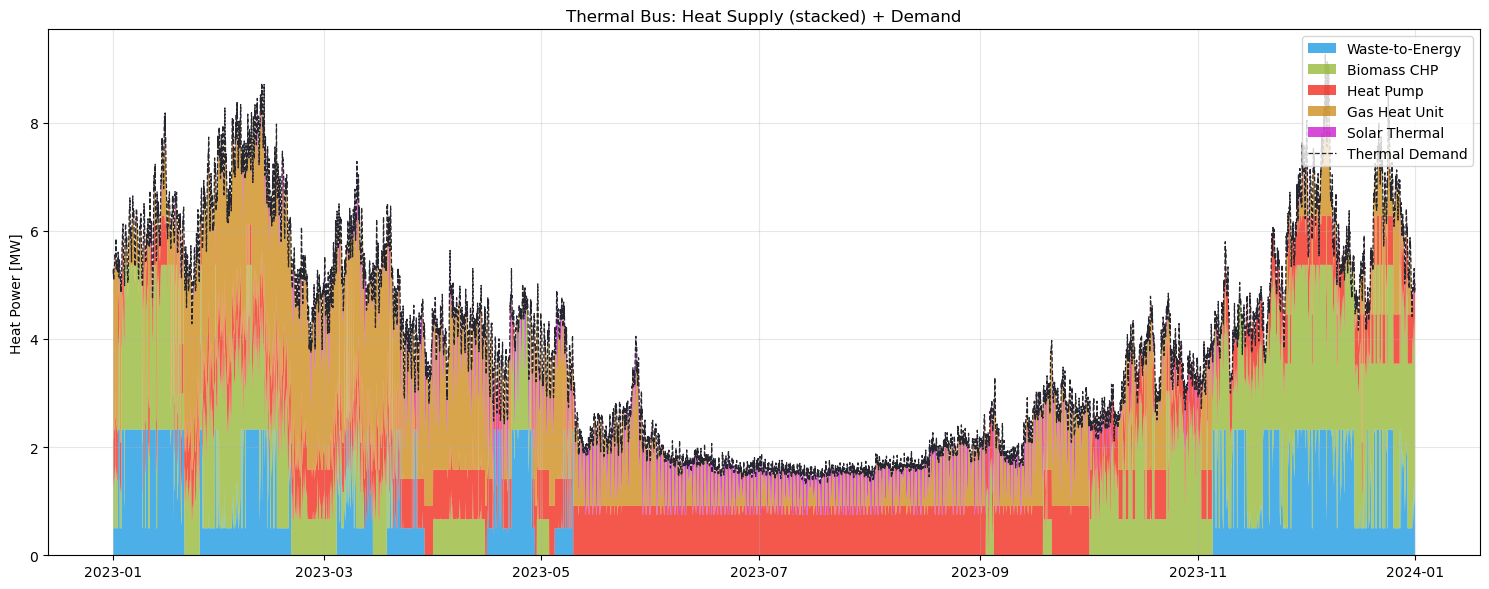

In [175]:
import matplotlib.pyplot as plt
from oemof.solph import views


thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]

start = "2023-01-01"
end = "2023-12-31"

seq = seq.loc[start:end]

# Column names from your results
col_wte = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass = (("chp_biomass", "thermal_bus"), "flow")
col_gas = (("heat_gas", "thermal_bus"), "flow")
col_hp = (("heat_pump", "thermal_bus"), "flow")
col_solar_th = (("solar_thermal", "thermal_bus"), "flow")

has_hp = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Desired order from BOTTOM (first) → TOP (last)
stack_order = [
    
    "wte", "biomass",    "hp",

    "gas",    "solar_th",

]
components = {
    "biomass": {
        "series": seq[col_biomass],
        "label": "Biomass CHP",
        "color": "#8AB020",
    },
    "gas": {
        "series": seq[col_gas],
        "label": "Gas Heat Unit",
        "color": "#C87E00",
    },
    "wte": {
        "series": seq[col_wte],
        "label": "Waste-to-Energy",
        "color": "#008DDF",
    },
    "hp": {
        "series": seq[col_hp] if has_hp else None,
        "label": "Heat Pump",
        "color": "#F01000",
    },
    "solar_th": {
        "series": seq[col_solar_th] if has_solar_th else None,
        "label": "Solar Thermal",
        "color": "#C500C8",
    },
}
supply_components = []
labels = []
colors = []

for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

plt.plot(
    seq.index,
    seq[(("thermal_bus", "thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

plt.title("Thermal Bus: Heat Supply (stacked) + Demand")
plt.ylabel("Heat Power [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

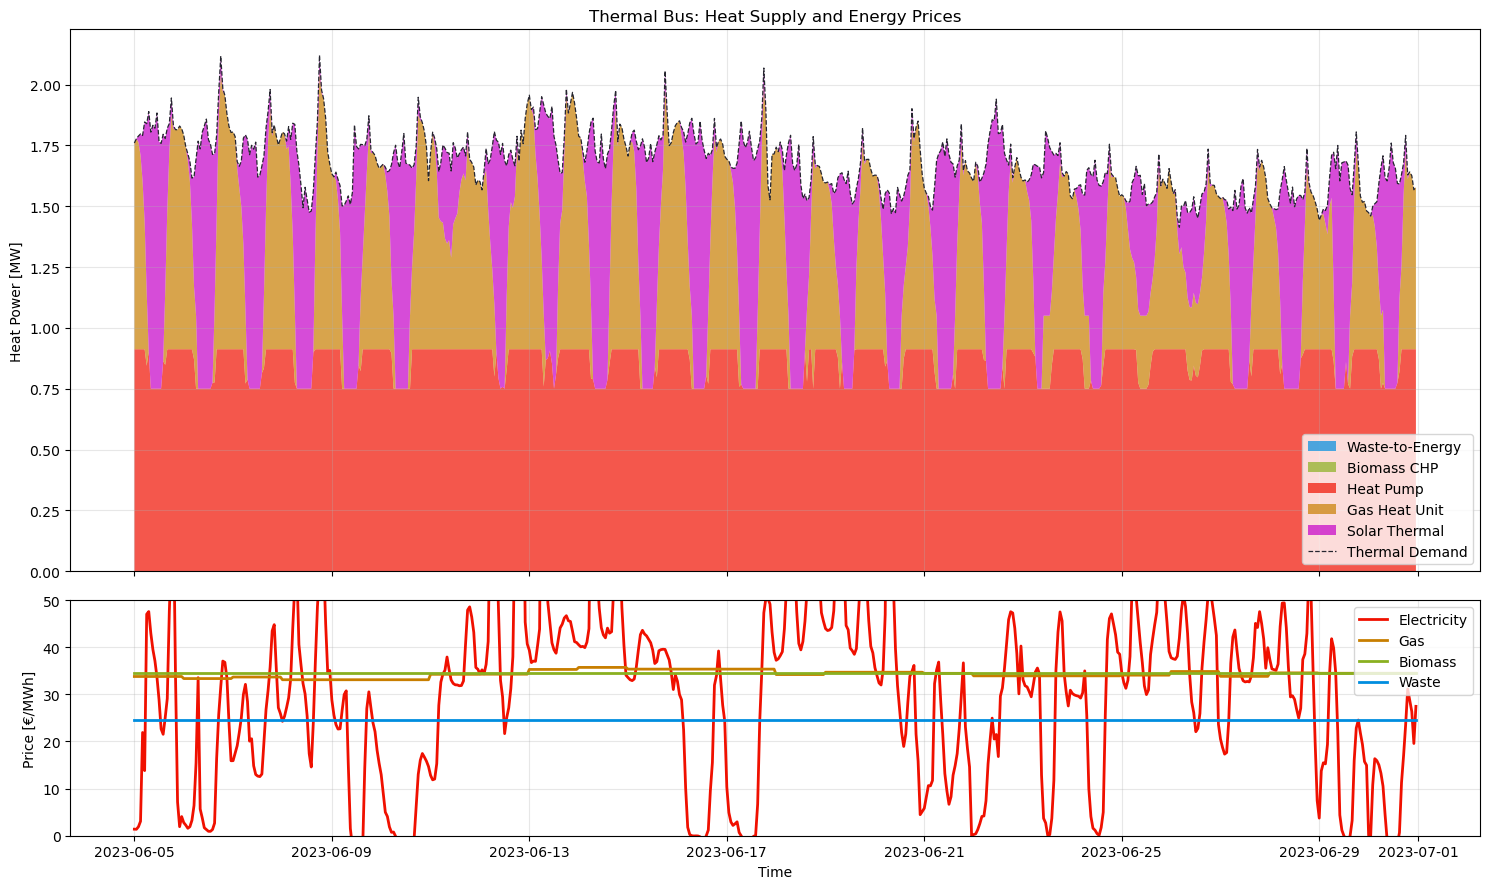

In [176]:
import matplotlib.pyplot as plt
from oemof.solph import views

# ---------------------------
# Thermal bus results
# ---------------------------
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]

start = "2023-06-05"
end = "2023-06-30"
seq = seq.loc[start:end]

# Column names
col_wte      = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass  = (("chp_biomass", "thermal_bus"), "flow")
col_gas      = (("heat_gas", "thermal_bus"), "flow")
col_hp       = (("heat_pump", "thermal_bus"), "flow")
col_solar_th = (("solar_thermal", "thermal_bus"), "flow")

has_hp       = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Stack order (bottom → top)
stack_order = ["wte", "biomass", "hp", "gas", "solar_th"]

components = {
    "biomass":  {"series": seq[col_biomass],              "label": "Biomass CHP",     "color": "#8AB020"},
    "gas":      {"series": seq[col_gas],                  "label": "Gas Heat Unit",   "color": "#C87E00"},
    "wte":      {"series": seq[col_wte],                  "label": "Waste-to-Energy", "color": "#008DDF"},
    "hp":       {"series": seq[col_hp] if has_hp else None,       "label": "Heat Pump",       "color": "#F01000"},
    "solar_th": {"series": seq[col_solar_th] if has_solar_th else None, "label": "Solar Thermal", "color": "#C500C8"},
}

supply_components, labels, colors = [], [], []
for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])

# ---------------------------
# Price data (bottom plot)
# ---------------------------
prices = data.loc[start:end, [
    "electricity_price_Euro_Per_MWh",
    "gas_price_Euro_Per_MWh",
    "biomass_Euro_Per_MWh",
    "waste_Euro_Per_MWh",
]]

# ---------------------------
# Plot: 2 rows, shared x-axis
# ---------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 9), sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.0]}
)

# --- TOP: thermal supply + demand
ax1.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

ax1.plot(
    seq.index,
    seq[(("thermal_bus", "thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

ax1.set_title("Thermal Bus: Heat Supply and Energy Prices")
ax1.set_ylabel("Heat Power [MW]")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

# --- BOTTOM: prices
ax2.plot(prices.index, prices["electricity_price_Euro_Per_MWh"],
         label="Electricity", linewidth=2.0, color = "#F01000")

ax2.plot(prices.index, prices["gas_price_Euro_Per_MWh"],
         label="Gas", linewidth=2.0, color = "#C87E00")

ax2.plot(prices.index, prices["biomass_Euro_Per_MWh"],
         label="Biomass", linewidth=2.0, color = "#8AB020")

ax2.plot(prices.index, prices["waste_Euro_Per_MWh"],
         label="Waste", linewidth=2.0, color = "#008DDF")

ax2.set_ylabel("Price [€/MWh]")
ax2.set_xlabel("Time")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")
# ax2.set_yscale("log")
ax2.set_ylim(0, 50)   # log scale cannot include 0

plt.tight_layout()
plt.show()


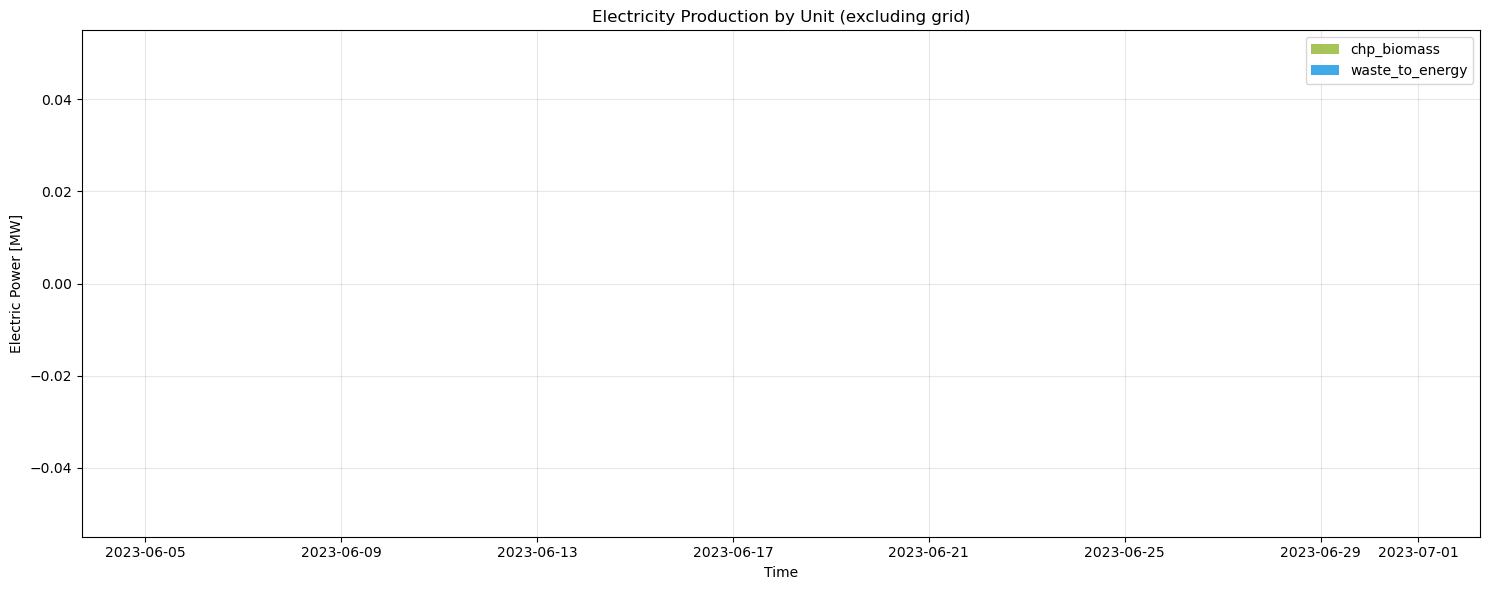

Electricity producers plotted: ['chp_biomass', 'waste_to_energy']


In [177]:
import matplotlib.pyplot as plt
from oemof.solph import views

# ---------------------------
# Electrical bus results
# ---------------------------
el_bus_view = views.node(results, "electrical_bus")
seq_el = el_bus_view["sequences"].iloc[:-1]

seq_el = seq_el.loc[start:end]

# ---------------------------
# Exclude grid-related nodes
# ---------------------------
exclude_nodes = {
    "electricity_grid",
    "grid",
    "grid_import",
    "grid_export"
}

# ---------------------------
# Auto-detect production columns
# ---------------------------
prod_cols = [
    c for c in seq_el.columns
    if isinstance(c, tuple)
    and len(c) == 2
    and isinstance(c[0], tuple)
    and c[0][1] == "electrical_bus"
    and c[1] == "flow"
    and c[0][0] not in exclude_nodes
]

# ---------------------------
# Color mapping (fixed)
# ---------------------------
color_map = {
    "chp_biomass": "#8AB020",       # biomass electricity
    "waste_to_energy": "#008DDF",   # waste electricity
}

# Build series, labels, colors
prod_series = []
prod_labels = []
prod_colors = []

for c in prod_cols:
    unit = c[0][0]
    prod_series.append(seq_el[c])
    prod_labels.append(unit)
    prod_colors.append(color_map.get(unit, "#999999"))  # fallback gray

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq_el.index,
    *prod_series,
    labels=prod_labels,
    colors=prod_colors,
    alpha=0.75,
)

plt.title("Electricity Production by Unit (excluding grid)")
plt.ylabel("Electric Power [MW]")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Debug (always useful)
print("Electricity producers plotted:", prod_labels)
